In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr

In [19]:
ds = xr.open_zarr("../data/interim/CM4Xp25_piControl-continued_transient_tracers_z.zarr")
ds_forced = xr.open_zarr("../data/interim/CM4Xp25_ssp585_transient_tracers_z.zarr/")

In [43]:
ds_surf = xr.open_zarr("../data/interim/CM4Xp25_ssp585_transient_tracers_surface.zarr/")

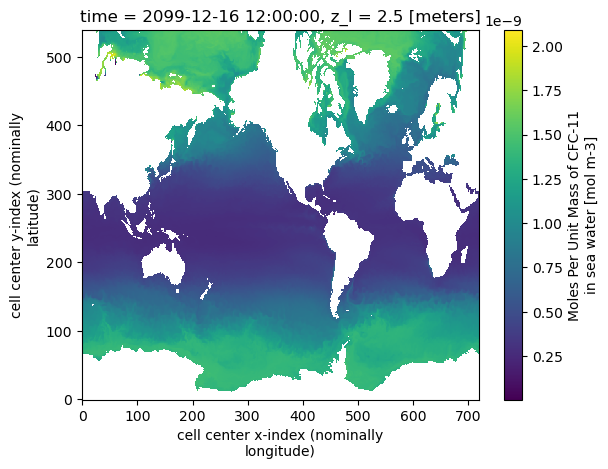

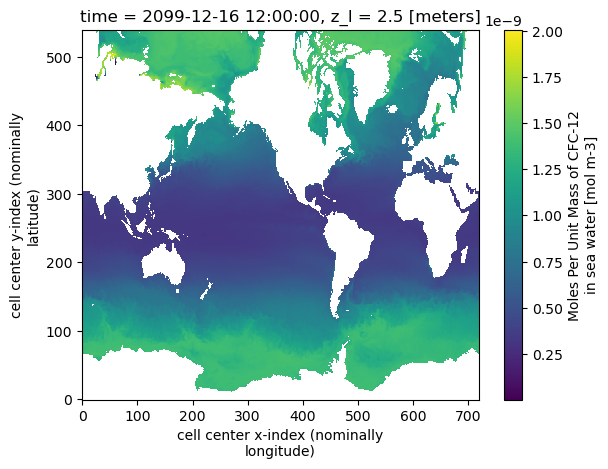

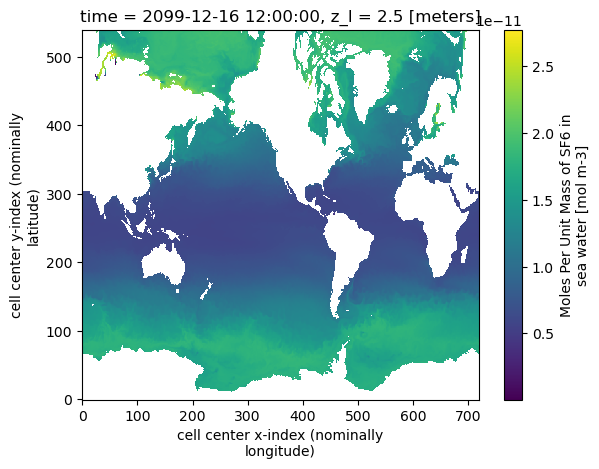

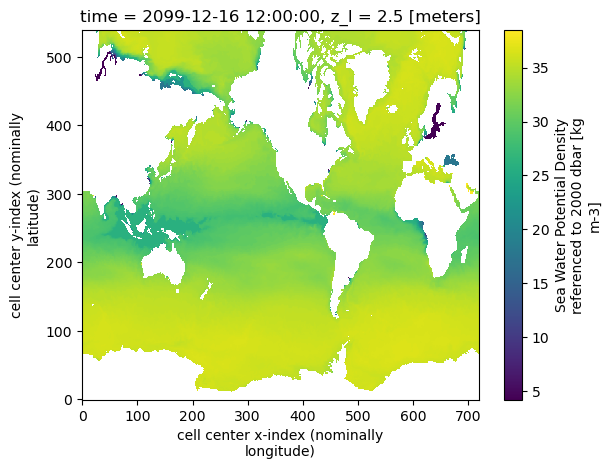

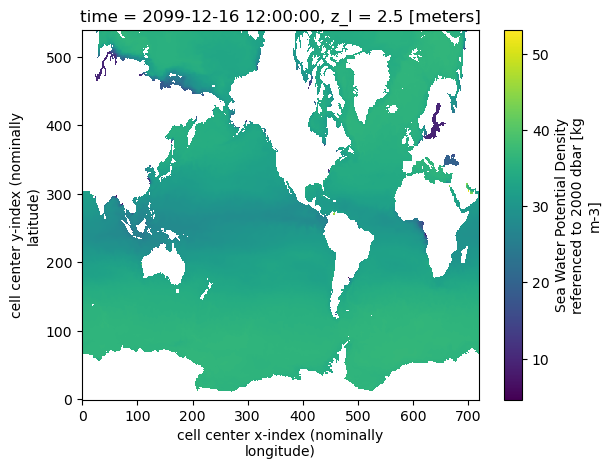

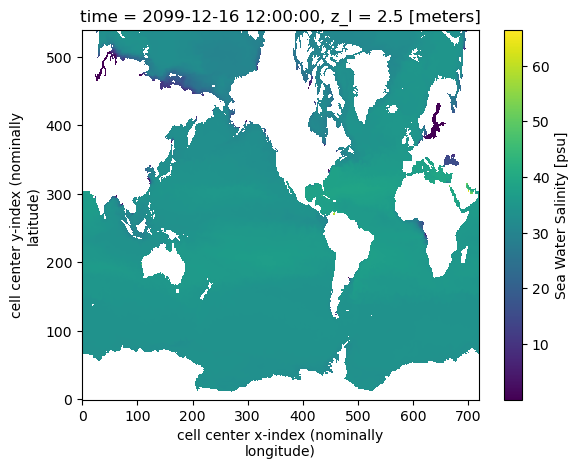

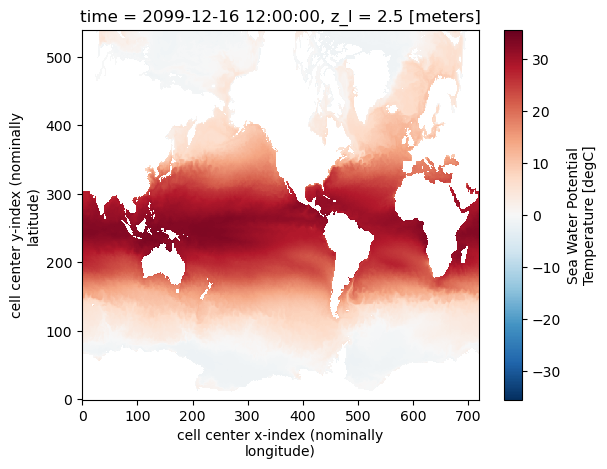

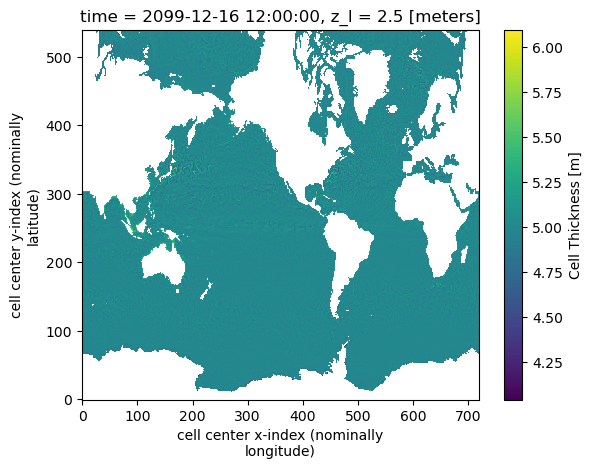

In [48]:
import matplotlib.pyplot as plt
for v in ds_surf.data_vars:
    plt.figure()
    ds_surf[v].isel(time=-1).plot()

In [20]:
tmp = ds.isel(year=-1).compute()
tmp_forced = ds_forced.isel(year=-1).compute()

In [109]:
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt

In [110]:
import warnings

import doralite
import gfdl_utils.core as gu
import CM4Xutils
import numpy as np
import xarray as xr
import xgcm

import gsw, xwmt
import zarr
import cftime
import gsw
import dask

import os
import sys
model = sys.argv[1]
testing = True

if model=="-f":
    model="CM4Xp25"

print(f"Subsample {model} transient tracer output.")
dim_coarsen_dict = {"CM4Xp25": {"X":2, "Y":2}, "CM4Xp125": {"X":4, "Y":4}}
dim_coarsen = dim_coarsen_dict[model]
odivs = CM4Xutils.exp_dict[model]

def load_tracer(exp, tracers, t="*"):
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_inert_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, tracers, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)
    
    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)
    
    return ds

def load_state(exp, t="*"):
    state_vars = ["thkcello", "thetao", "so"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_z" if "p125" in meta["expName"] else "ocean_monthly_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)

    grid = CM4Xutils.ds_to_grid(ds)
    
    # Compute potential density
    diagnose_sigma2_offline(grid)
    
    return grid._ds

def load_rho2(exp, t="*"):
    # Load thickness of density layers
    state_vars = ["thkcello"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_rho2"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'rho2_l':ds.rho2_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)

    grid_rho2 = CM4Xutils.ds_to_grid(ds)

    # Get depths of density interfaces
    infer_z(grid_rho2)

    return grid_rho2

def assign_historical_dates(ds_ctrl):
    # Align dates of a control simulation (with nominal dates starting from year 1)
    # to a historically-referenced simulation (e.g. with dates starting from 1850)
    if "year" in ds_ctrl.dims:
        year_ctrl = ds_ctrl.year.copy()
        ds_ctrl = ds_ctrl.rename({"year": "year_ctrl"})
        historical_equivalent_dates = xr.DataArray(
            np.array([y+1749 for y in year_ctrl]),
            dims=("year_ctrl",)
        )
        ds_ctrl = (
            ds_ctrl
            .assign_coords({"year": historical_equivalent_dates})
            .swap_dims({"year_ctrl": "year"})
        )
    elif "time" in ds_ctrl.dims:
        time_ctrl = ds_ctrl.time.copy()
        ds_ctrl = ds_ctrl.rename({"time": "time_ctrl"})
        historical_equivalent_dates = xr.DataArray(
            np.array([
                cftime.DatetimeNoLeap(
                    int(d.dt.year) + 1749,
                    int(d.dt.month),
                    int(d.dt.day),
                    0, 0, 0, 0,
                    has_year_zero=True
                )
                for d in time_ctrl
            ]),
            dims=("time_ctrl",)
        )
        ds_ctrl = (
            ds_ctrl
            .assign_coords({"time": historical_equivalent_dates})
            .swap_dims({"time_ctrl": "time"})
        )
    
    return ds_ctrl

def add_estimated_layer_interfaces(ds):
    return ds.assign_coords({"z_i": xr.DataArray(
        np.concatenate([[0], 0.5*(ds.z_l.values[1:]+ds.z_l.values[0:-1]), [6750]]),
        dims=('z_i',)
    )})

def diagnose_sigma2_offline(grid):
    grid._ds["sigma2_offline"] = xr.apply_ufunc(
        gsw.sigma2,
        grid._ds.so,
        grid._ds.thetao,
        dask="parallelized"
    ).rename("sigma2_offline")
    grid._ds["sigma2_offline"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density',
        'description': "Diagnosed offline using the `gsw.sigma2` function on `thetao` and `so` on depth levels."
    }

def regrid_sigma2_from_rho2_diags(ds, grid_rho2):
    grid_rho2._ds["sigma2"] = grid_rho2._ds["rho2_l"] - 1000.
    sigma2 = (
        grid_rho2.transform(
            grid_rho2._ds.sigma2*grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
        / grid_rho2.transform(
            grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
    ).transpose("time", "z_l", "yh", "xh")
    sigma2 = sigma2.assign_coords({k:ds[k] for k in ds.coords if k in sigma2.coords})
    ds["sigma2"] = sigma2
    ds["sigma2"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density',
        'description': "Regridded offline based on online thicknesses between fixed rho2 levels."
    }

def infer_z(grid, zero_ssh=True):
    zl = grid.axes['Z'].coords['center']
    zi = grid.axes['Z'].coords['outer']

    if zero_ssh:
        ssh_ref = 0 
    else:
        # CM4Xp25 does not have col_height variable available, so need to compute from thkcello
        if "col_height" not in grid._ds.data_vars:
            grid._ds["col_height"] = grid._ds["thkcello"].sum(zl)
            grid._ds["col_height"].attrs = {
                'long_name': 'The height of the water column',
                 'units': 'm',
                 'cell_methods': 'area:mean yh:mean xh:mean time: mean',
                 'cell_measures': 'area: areacello',
                 'time_avg_info': 'average_T1,average_T2,average_DT'
            }
        ssh_ref = grid._ds.col_height - grid._ds.deptho

    # Interface depths
    thkcello_cumsum = (
        xr.concat([
            xr.zeros_like(grid._ds.thkcello.isel({zl:0})).expand_dims({zl:[0]}),
            grid._ds.thkcello.cumsum(zl),
        ],dim=zl)
        .rename({zl:zi})
        .assign_coords({zi:grid._ds[zi].values})
    )
    grid._ds["z_i"] = (
        (thkcello_cumsum - ssh_ref)
        .transpose("time", zi, "yh", "xh")
    ).chunk({zi: grid._ds[zi].size})
    grid._ds["z_i"].attrs = {
        'long_name': 'depth of layer interfaces',
        'units': 'm',
        'cell_methods': f'area:mean {zi}:point yh:mean xh:mean time: mean',
        'cell_measures': 'area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

    # Center depths
    zl_extended = np.concatenate((
        grid._ds[zi][np.array([0])].values,
        grid._ds[zl].values,
        grid._ds[zi][np.array([-1])].values
    ))

    grid._ds["thkcello_i"] = grid.transform(
        grid._ds["thkcello"].fillna(0.),
        "Z",
        zl_extended,
        method="conservative",
    ).assign_coords({zi:grid._ds[zi].values}).transpose("time", zi, "yh", "xh")

    grid._ds["z_l"] = (
        (grid.cumsum(grid._ds.thkcello_i, "Z", to="center") - ssh_ref)
        .transpose("time", zl, "yh", "xh")
    ).chunk({zl: grid._ds[zl].size})
    grid._ds["z_l"].attrs = {
        'long_name': 'depth of layer centers',
        'units': 'm',
        'cell_methods': f'area:mean {zl}:point yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

def load(exp, tracers, t="*"):
    try:
        ds_tracer = load_tracer(exp, tracers, t=t)
    except:
        ds_tracer = xr.Dataset()
    ds_state = load_state(exp, t=t)
    ds = xr.merge([ds_tracer, ds_state], compat="override")

    # Get accurate density field on depth levels from thkcello(rho2_l)
    grid_rho2 = load_rho2(exp, t=t)
    regrid_sigma2_from_rho2_diags(ds, grid_rho2)
    
    grid = CM4Xutils.ds_to_grid(ds)
    return grid

time_ranges = {
    "CM4Xp25": {
        "historical": [1850, 2015],
        "ssp585": [2015, 2100],
        "piControl": [101, 361],
        "piControl-continued": [361, 651],
    },
    "CM4Xp125": {
        "historical": [1850, 2015],
        "ssp585": [2015, 2100],
        "piControl": [101, 451],
        "piControl-continued": [451, 651],
    }
}

with warnings.catch_warnings(action='ignore', category=UserWarning):
    for exp, t_range in time_ranges[model].items():
        coarse_path = f"../data/interim/{model}_{exp}_transient_tracers_z.zarr"  # one per exp
        surface_path = f"../data/interim/{model}_{exp}_transient_tracers_surface.zarr"  # one per exp

        mode = "w" # overwrite if .zarr already file exists
        for t in np.arange(t_range[0], t_range[1], 5):
            tstr = f"{str(t).zfill(4)}*"
            print(f"Coarsening tracers for {model}-{exp} for {tstr}")

            with dask.config.set(**{'array.slicing.split_large_chunks': False}):
                grid = load(odivs[exp], ["cfc11", "cfc12", "sf6"], t=tstr)
                
                ds_mean = grid._ds.groupby("time.year").mean("time")
                ds_coarse = CM4Xutils.coarsen.horizontally_coarsen(ds_mean, grid, dim_coarsen)
                
                ds_surface = grid._ds.isel(z_l=[0])
                ds_surface_coarse = CM4Xutils.coarsen.horizontally_coarsen(ds_surface, grid, dim_coarsen)
                
                if "piControl" in exp:
                    ds_coarse = assign_historical_dates(ds_coarse)
                    ds_surface_coarse = assign_historical_dates(ds_surface_coarse)

            break
        break

Subsample CM4Xp25 transient tracer output.
Coarsening tracers for CM4Xp25-historical for 1850*
Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: depth `z_`
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: density `rho2`
Inferring Z grid coordinate: depth `z_`
Skipping variable average_DT because `cell_methods` attribute not defined.
Skipping variable average_DT because `cell_methods` attribute not defined.
Skipping variable average_T1 because `cell_methods` attribute not defined.
Skipping variable average_T2 because `cell_methods` attribute not defined.
Skipping variable time_bnds because `cell_methods` attribute not defined.


In [111]:
with ProgressBar():
    ds_coarse_tmp = ds_coarse.isel(year=0).compute()
    ds_surface_coarse_tmp = ds_surface_coarse.isel(time=slice(0, 12)).compute()

[########################################] | 100% Completed | 53.18 s
[########################################] | 100% Completed | 48.85 s


In [76]:
ds = grid._ds

grid_rho2._ds["sigma2"] = grid_rho2._ds["rho2_l"] - 1000.
volcello = grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.)
tmp1 = grid_rho2.transform(
    grid_rho2._ds.sigma2*volcello,
    "Z",
    target=ds.z_i,
    target_data=grid_rho2._ds.z_i,
    method="conservative"
).rename({"z_i":"z_l"}).transpose("time", "z_l", "yh", "xh")
tmp2 = grid_rho2.transform(
    volcello,
    "Z",
    target=ds.z_i,
    target_data=grid_rho2._ds.z_i,
    method="conservative"
).rename({"z_i":"z_l"}).transpose("time", "z_l", "yh", "xh")

(100.0, 300.0)

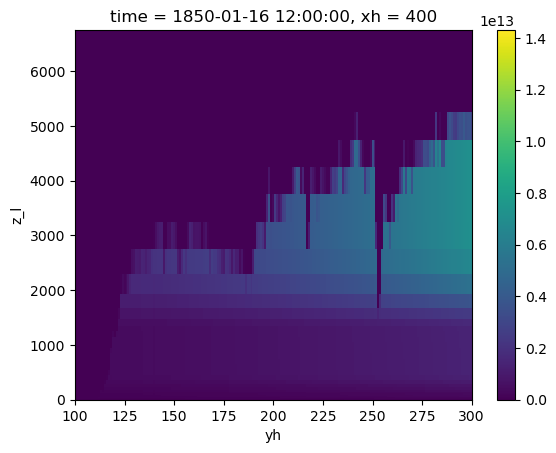

In [77]:
tmp1.isel(xh=400, time=0).plot()
plt.xlim(100, 300)

(100.0, 300.0)

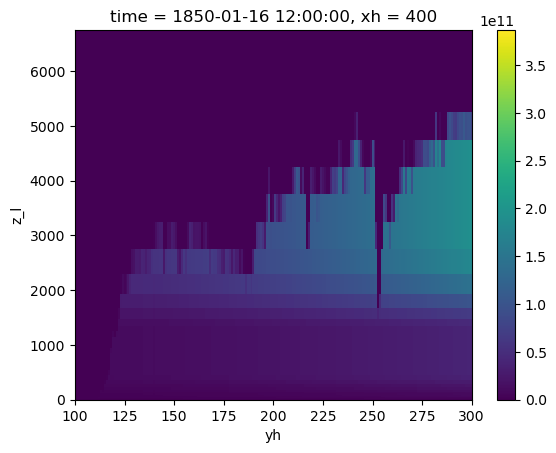

In [78]:
tmp2.isel(xh=400, time=0).plot()
plt.xlim(100, 300)

(4000.0, 1500.0)

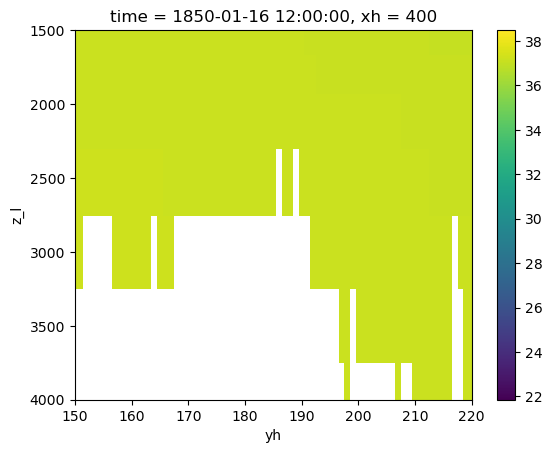

In [79]:
(tmp1.isel(xh=400, time=0)/tmp2.isel(xh=400, time=0)).plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

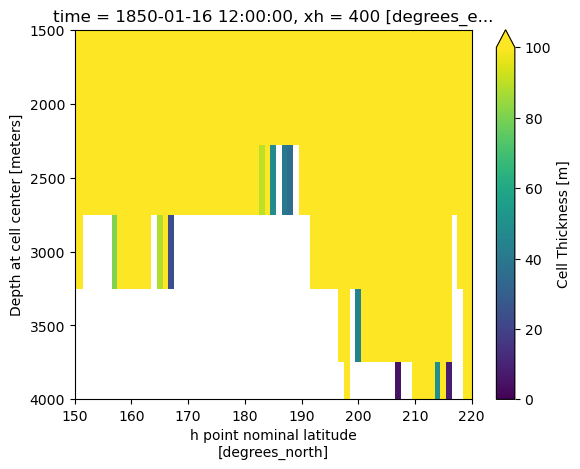

In [80]:
grid._ds.isel(xh=400, time=0).thkcello.plot(vmin=0, vmax=100)
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

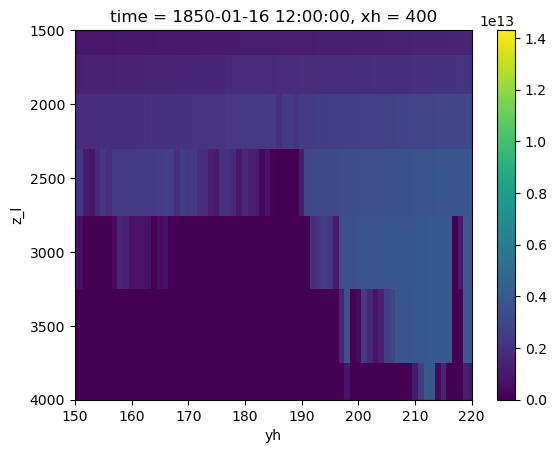

In [81]:
tmp1.isel(xh=400, time=0).plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

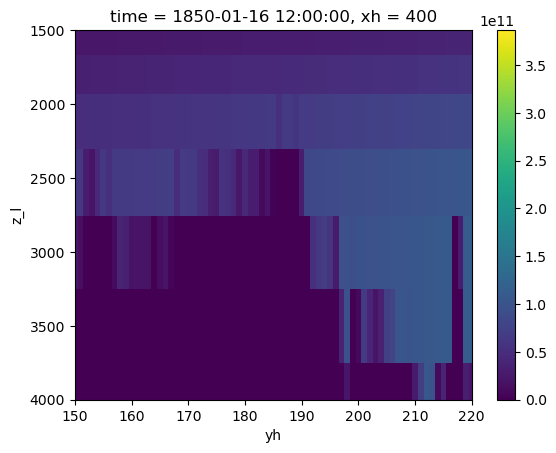

In [64]:
tmp2.isel(xh=400, time=0).plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

In [86]:
tmp3 = (tmp1/tmp2).fillna(0.)
tmp3 = tmp3.assign_coords({k:ds[k] for k in ds.coords if k in tmp3.coords})

(4000.0, 1500.0)

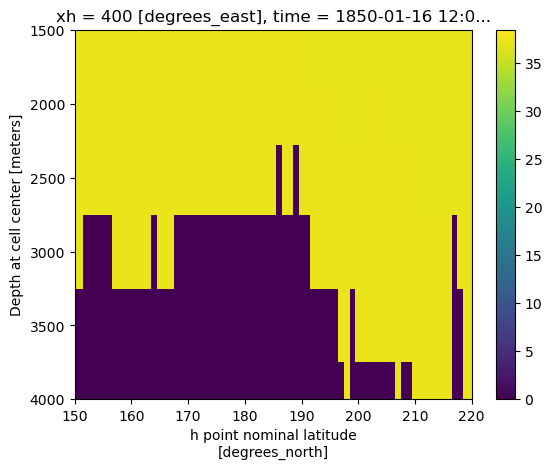

In [87]:
tmp3.isel(xh=400, time=0).plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

In [93]:
tmp4 = (tmp3*grid._ds.thkcello.fillna(0.))

(4000.0, 1500.0)

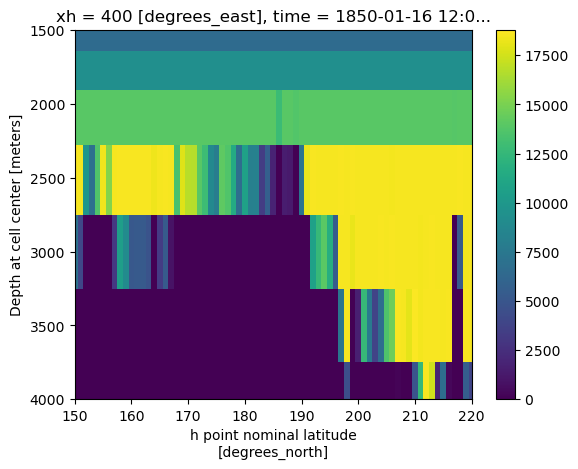

In [94]:
tmp4.isel(xh=400, time=0).plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

In [100]:
num = tmp4.isel(xh=400, time=0).coarsen({"yh":2}).sum()
dem = grid._ds.thkcello.isel(xh=400, time=0).fillna(0.).coarsen({"yh":2}).sum()
tmp5 = num/dem

(4000.0, 1500.0)

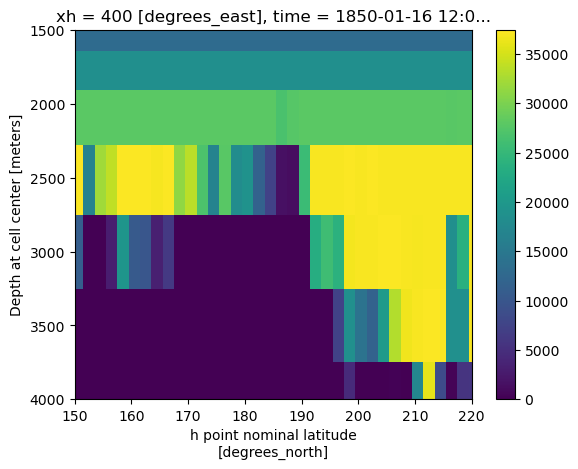

In [97]:
num.plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

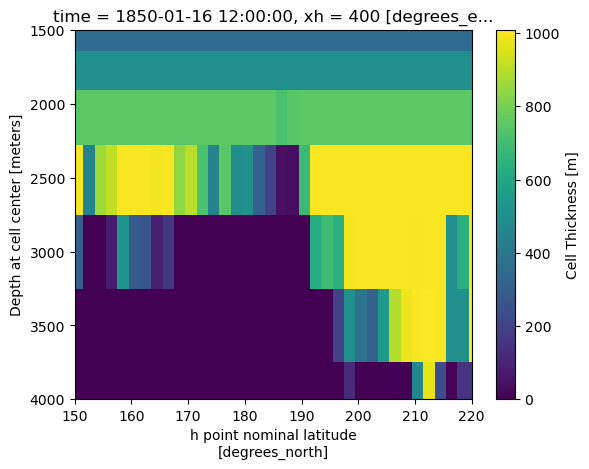

In [99]:
dem.plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

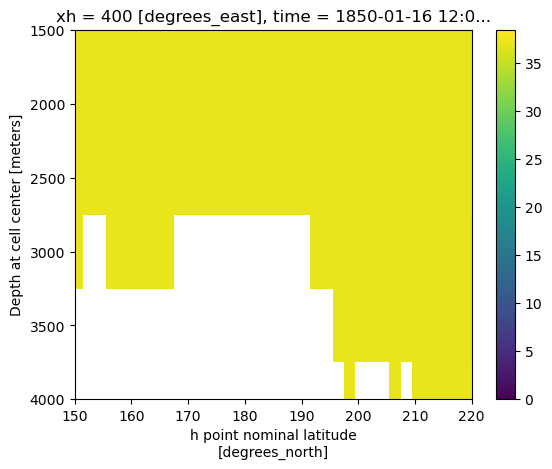

In [101]:
tmp5.plot()
plt.xlim(150, 220)
plt.ylim(4000, 1500)

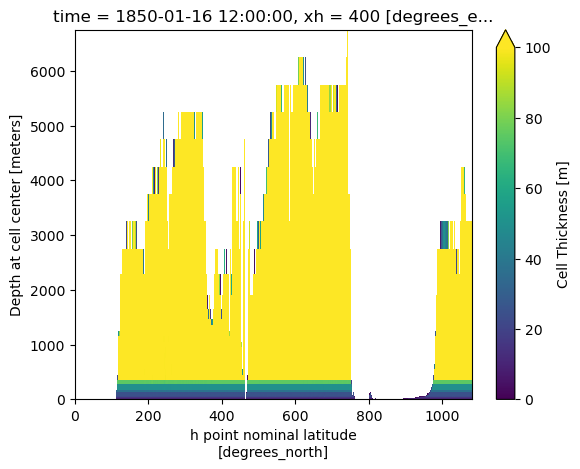

In [57]:
grid._ds.isel(xh=400, time=0).thkcello.plot(vmin=0, vmax=100)

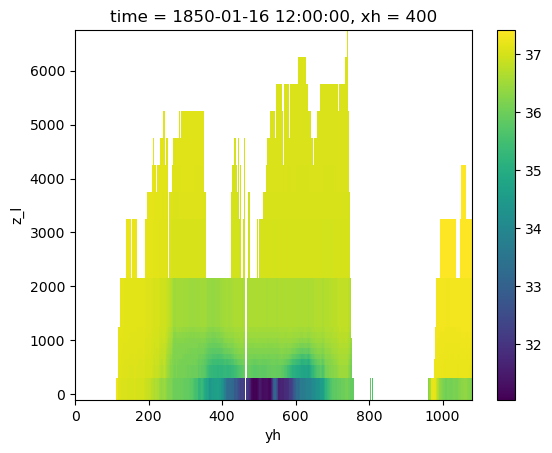

In [58]:
tmp3.plot()
#plt.xlim(150, 220)
#plt.ylim(4000, 1500)

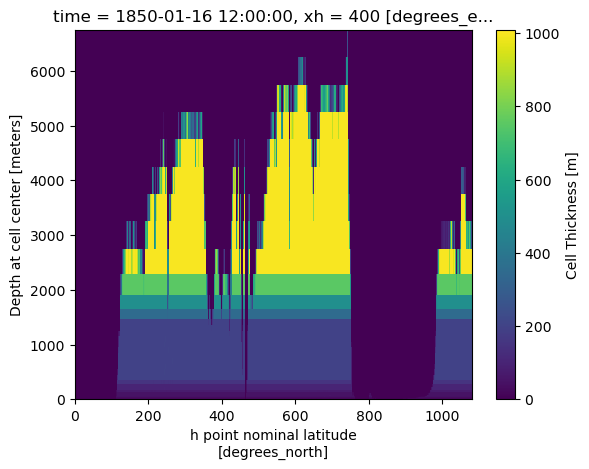

In [43]:
grid._ds.isel(xh=400, time=0).thkcello.fillna(0.).coarsen({"yh":2}).sum().plot()

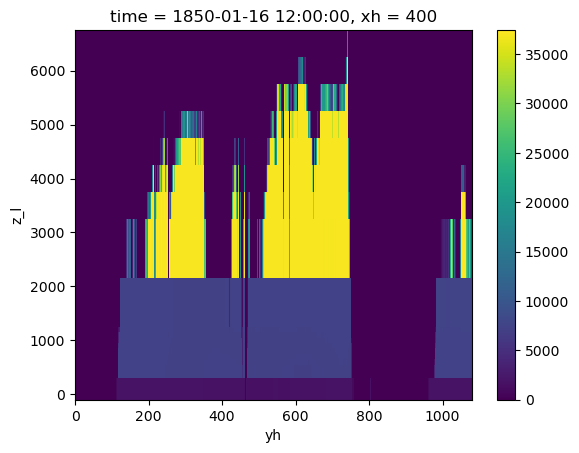

In [42]:
(tmp1/tmp2*grid._ds.thkcello.fillna(0.)).isel(xh=400, time=0).coarsen({"yh":2}).sum().plot()

In [ ]:
grid_rho2._ds.isel(xh=400, time=0).plot(vmin=0, vmax=100)
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(4000.0, 1500.0)

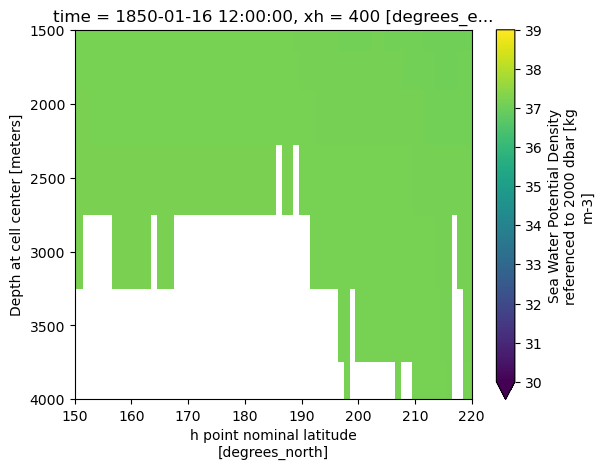

In [20]:
grid._ds.isel(xh=400, time=0).sigma2.plot(vmin=30, vmax=39)
plt.xlim(150, 220)
plt.ylim(4000, 1500)

(100.0, 300.0)

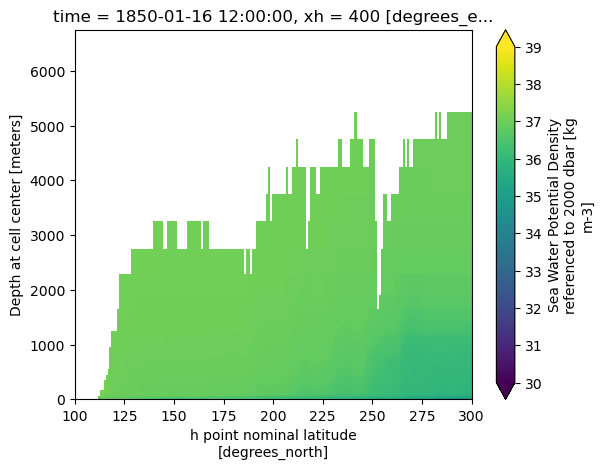

In [336]:
grid._ds.isel(xh=400, time=0).sigma2_offline.plot(vmin=30, vmax=39)
plt.xlim(100, 300)

(100.0, 300.0)

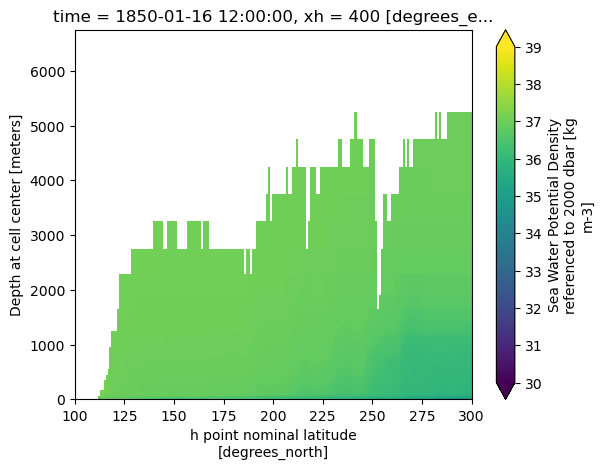

In [114]:
grid._ds.isel(xh=400, time=0).sigma2_offline.plot(vmin=30, vmax=39)
plt.xlim(100, 300)

(50.0, 150.0)

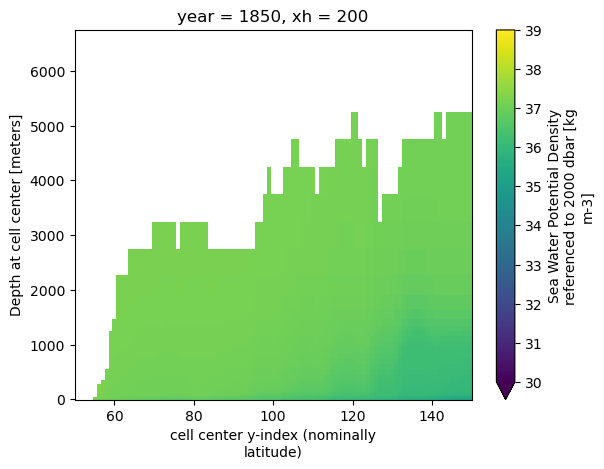

In [113]:
ds_coarse_tmp.isel(xh=200).sigma2.plot(vmin=30, vmax=39)
plt.xlim(50, 150)

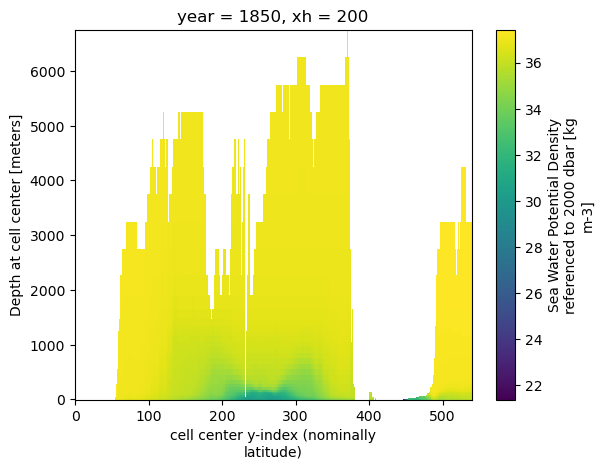

In [117]:
ds_coarse_tmp.isel(xh=200).sigma2.plot()

In [120]:
with ProgressBar():
    ds_coarse_tmp = ds_coarse.sigma2.isel(year=0).compute()

[                                        ] | 0% Completed | 46.01 sms


KeyboardInterrupt: 

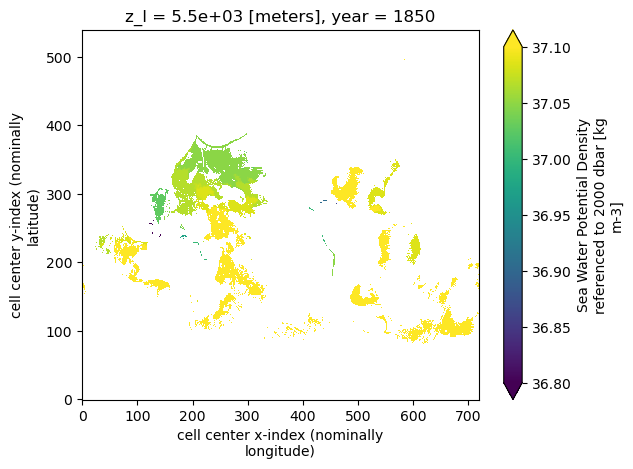

In [144]:
ds_coarse_tmp.sigma2.isel(z_l=32).plot(vmin=36.8, vmax=37.1)

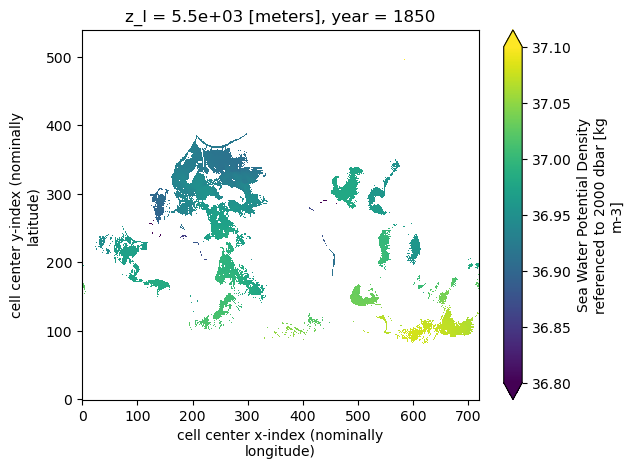

In [143]:
ds_coarse_tmp.sigma2_offline.isel(z_l=32).plot(vmin=36.8, vmax=37.1)

In [ ]:
ds_coarse.sigma2.isel(year=0, z_l=25).plot()
plt.xlim(500, 600)
plt.ylim(375, 450)

In [295]:
import sys
import os

In [259]:
import warnings

import doralite
import gfdl_utils.core as gu
import CM4Xutils
import numpy as np
import xarray as xr
import xgcm

import gsw, xwmt
import zarr
import cftime
import gsw
import dask

import os
import sys

In [260]:
for k in grid._ds.dims:
    print(k)

time
z_l
yh
xh
nv
yq
xq
z_i


In [261]:
ds = xr.open_zarr("../data/interim/CM4Xp25_historical_transient_tracers_z.zarr")

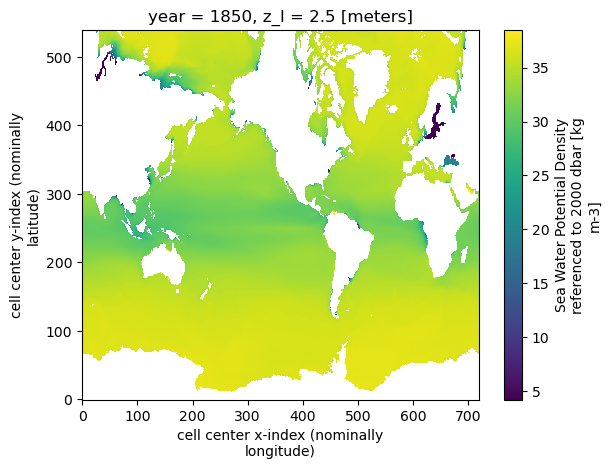

In [266]:
ds.sigma2.isel(year=0, z_l=0).plot()

In [107]:
grid._ds.sigma2.isel(year=0, z_l=25).plot(vmin=36.8, vmax=37.2)

ValueError: Dimensions {'year'} do not exist. Expected one or more of ('time', 'z_l', 'yh', 'xh')

(375.0, 450.0)

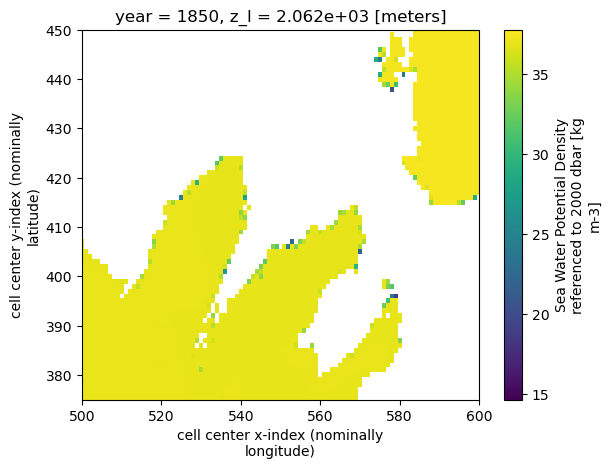

In [288]:
ds.sigma2.isel(year=0, z_l=25).plot()
plt.xlim(500, 600)
plt.ylim(375, 450)

(375.0, 450.0)

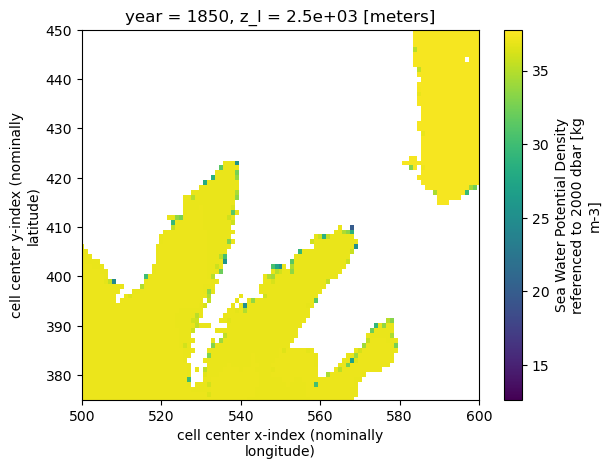

In [289]:
ds.sigma2.isel(year=0, z_l=26).plot()
plt.xlim(500, 600)
plt.ylim(375, 450)

In [218]:
model = "CM4Xp125"
#model = sys.argv[1]
testing = False

print(f"Subsample {model} transient tracer output.")
dim_coarsen_dict = {"CM4Xp25": {"X":2, "Y":2}, "CM4Xp125": {"X":4, "Y":4}}
dim_coarsen = dim_coarsen_dict[model]
odivs = CM4Xutils.exp_dict[model]

def load_tracer(exp, tracers, t="*"):
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_inert_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, tracers, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)
    
    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)
    
    return ds

def load_state(exp, t="*"):
    state_vars = ["thkcello", "thetao", "so"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)

    grid = CM4Xutils.ds_to_grid(ds)
    
    # Compute potential density
    diagnose_sigma2_offline(grid)
    
    return grid._ds

def load_rho2(exp, t="*"):
    # Load thickness of density layers
    state_vars = ["thkcello"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_rho2"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'rho2_l':ds.rho2_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)

    grid_rho2 = CM4Xutils.ds_to_grid(ds)

    # Get depths of density interfaces
    infer_z(grid_rho2)

    return grid_rho2

def assign_historical_dates(ds_ctrl):
    # Align dates of a control simulation (with nominal dates starting from year 1)
    # to a historically-referenced simulation (e.g. with dates starting from 1850)
    year_ctrl = ds_ctrl.year.copy()
    ds_ctrl = ds_ctrl.rename({"year": "year_ctrl"})
    historical_equivalent_dates = xr.DataArray(
        np.array([y+1749 for y in year_ctrl]),
        dims=("year_ctrl",)
    )
    ds_ctrl = (
        ds_ctrl
        .assign_coords({"year": historical_equivalent_dates})
        .swap_dims({"year_ctrl": "year"})
    )
    
    return ds_ctrl

def add_estimated_layer_interfaces(ds):
    return ds.assign_coords({"z_i": xr.DataArray(
        np.concatenate([[0], 0.5*(ds.z_l.values[1:]+ds.z_l.values[0:-1]), [6750]]),
        dims=('z_i',)
    )})

def diagnose_sigma2_offline(grid):
    grid._ds["sigma2_offline"] = xr.apply_ufunc(
        gsw.sigma2,
        grid._ds.so,
        grid._ds.thetao,
        dask="parallelized"
    ).rename("sigma2_offline")
    grid._ds["sigma2_offline"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density',
        'description': "Diagnosed offline using the `gsw.sigma2` function on `thetao` and `so` on depth levels."
    }

def regrid_sigma2_from_rho2_diags(ds, grid_rho2):
    grid_rho2._ds["sigma2"] = grid_rho2._ds["rho2_l"] - 1000.
    sigma2 = (
        grid_rho2.transform(
            grid_rho2._ds.sigma2*grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
        / grid_rho2.transform(
            grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
    ).transpose("time", "z_l", "yh", "xh")
    sigma2 = sigma2.assign_coords({k:ds[k] for k in ds.coords if k in sigma2.coords})
    ds["sigma2"] = sigma2

def infer_z(grid, zero_ssh=True):
    zl = grid.axes['Z'].coords['center']
    zi = grid.axes['Z'].coords['outer']

    if zero_ssh:
        ssh_ref = 0 
    else:
        # CM4Xp25 does not have col_height variable available, so need to compute from thkcello
        if "col_height" not in grid._ds.data_vars:
            grid._ds["col_height"] = grid._ds["thkcello"].sum(zl)
            grid._ds["col_height"].attrs = {
                'long_name': 'The height of the water column',
                 'units': 'm',
                 'cell_methods': 'area:mean yh:mean xh:mean time: mean',
                 'cell_measures': 'area: areacello',
                 'time_avg_info': 'average_T1,average_T2,average_DT'
            }
        ssh_ref = grid._ds.col_height - grid._ds.deptho

    # Interface depths
    thkcello_cumsum = (
        xr.concat([
            xr.zeros_like(grid._ds.thkcello.isel({zl:0})).expand_dims({zl:[0]}),
            grid._ds.thkcello.cumsum(zl),
        ],dim=zl)
        .rename({zl:zi})
        .assign_coords({zi:grid._ds[zi].values})
    )
    grid._ds["z_i"] = (
        (thkcello_cumsum - ssh_ref)
        .transpose("time", zi, "yh", "xh")
    ).chunk({zi: grid._ds[zi].size})
    grid._ds["z_i"].attrs = {
        'long_name': 'depth of layer interfaces',
        'units': 'm',
        'cell_methods': f'area:mean {zi}:point yh:mean xh:mean time: mean',
        'cell_measures': 'area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

    # Center depths
    zl_extended = np.concatenate((
        grid._ds[zi][np.array([0])].values,
        grid._ds[zl].values,
        grid._ds[zi][np.array([-1])].values
    ))

    grid._ds["thkcello_i"] = grid.transform(
        grid._ds["thkcello"].fillna(0.),
        "Z",
        zl_extended,
        method="conservative",
    ).assign_coords({zi:grid._ds[zi].values}).transpose("time", zi, "yh", "xh")

    grid._ds["z_l"] = (
        (grid.cumsum(grid._ds.thkcello_i, "Z", to="center") - ssh_ref)
        .transpose("time", zl, "yh", "xh")
    ).chunk({zl: grid._ds[zl].size})
    grid._ds["z_l"].attrs = {
        'long_name': 'depth of layer centers',
        'units': 'm',
        'cell_methods': f'area:mean {zl}:point yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

def load(exp, tracers, t="*"):
    try:
        ds_tracer = load_tracer(exp, tracers, t=t)
    except:
        ds_tracer = xr.Dataset()
    ds_state = load_state(exp, t=t)
    ds = xr.merge([ds_tracer, ds_state], compat="override")

    # Get accurate density field on depth levels from thkcello(rho2_l)
    grid_rho2 = load_rho2(exp, t=t)
    regrid_sigma2_from_rho2_diags(ds, grid_rho2)

    # Reduce data volume by averaging
    ds = ds.groupby("time.year").mean("time")
    
    grid = CM4Xutils.ds_to_grid(ds)
    return grid

Subsample CM4Xp125 transient tracer output.


In [219]:
exp = CM4Xutils.exp_dict["CM4Xp125"]["piControl"]

In [220]:
grid = load(exp, ["cfc11", "cfc12", "sf6"], t="0451*")

Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: depth `z_`
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: density `rho2`


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(


Inferring Z grid coordinate: depth `z_`


In [5]:
from dask.diagnostics import ProgressBar

In [238]:
with ProgressBar():
    sigma2 = grid._ds["sigma2"].isel(year=0, xh=1100).compute()

[########################################] | 100% Completed | 8.67 ss


In [239]:
with ProgressBar():
    sigma2_offline = grid._ds["sigma2_offline"].isel(year=0, xh=1100).compute()

[########################################] | 100% Completed | 9.00 sms


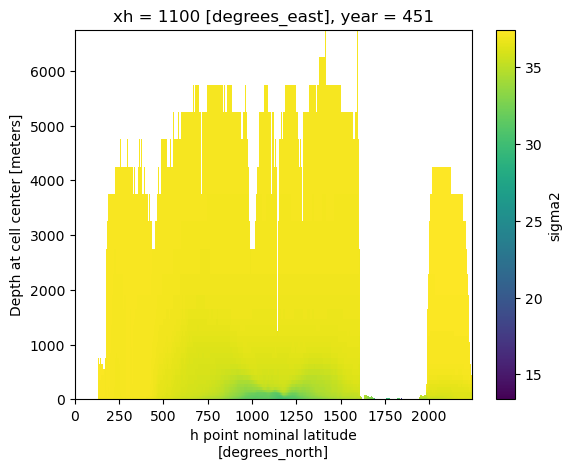

In [240]:
sigma2.plot()

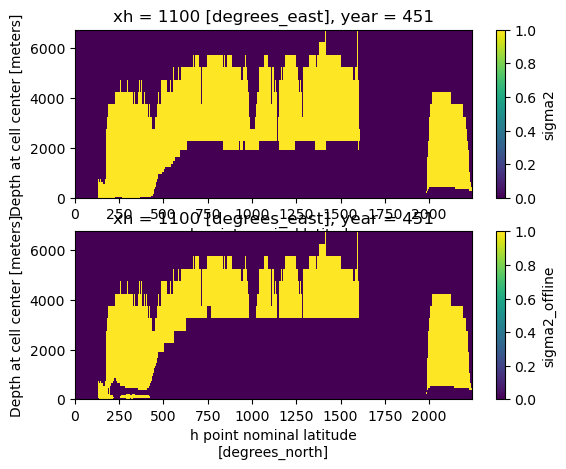

In [248]:
s = 36.9
plt.subplot(2,1,1)
(sigma2 > s).plot()
plt.subplot(2,1,2)
(sigma2_offline > s).plot()

Text(0.5, 1.0, 'gsw.sigma2(thetao,so) on z_l minus sigma2 estimated from rho2_i interface heights')

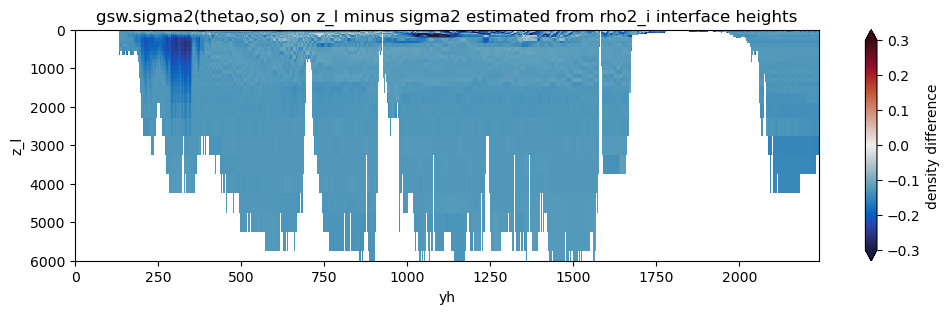

In [152]:
import cmocean as cm
import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
pc = (ds.sigma2.isel(time=0, xh=1000) - tmp.isel(time=0, xh=1000).values).plot(
    x="yh", vmin=-0.3, vmax=0.3, extend="both",
    cmap=cm.cm.balance
)
pc.colorbar.set_label("density difference")
plt.ylim(6000, 0)
plt.title("gsw.sigma2(thetao,so) on z_l minus sigma2 estimated from rho2_i interface heights")

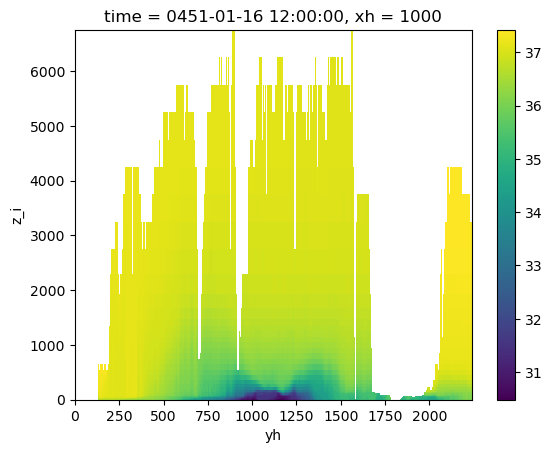

In [135]:
tmp.isel(time=0, xh=1000).plot(x="yh")

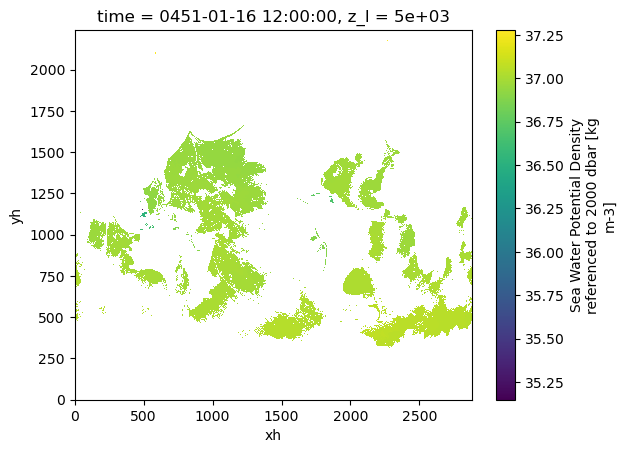

In [132]:
ds.sigma2.isel(time=0, z_l=-4).plot()

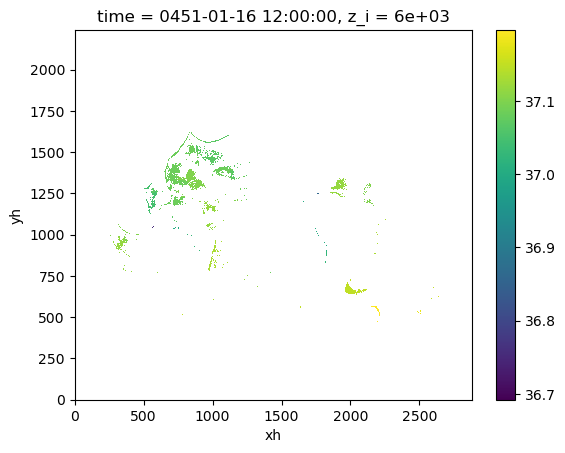

In [126]:
tmp.isel(time=0, z_i=-2).plot()

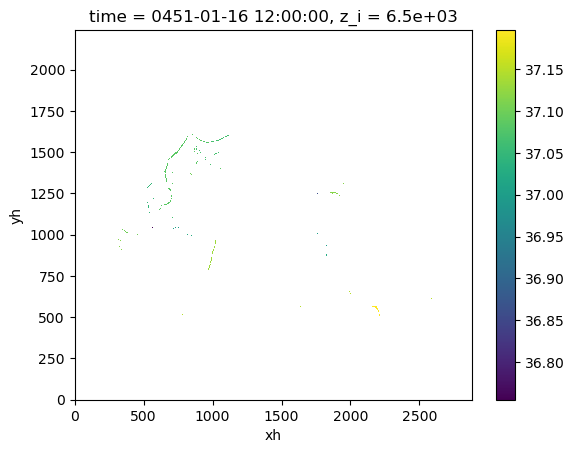

In [125]:
tmp.isel(time=0, z_i=-1).plot()

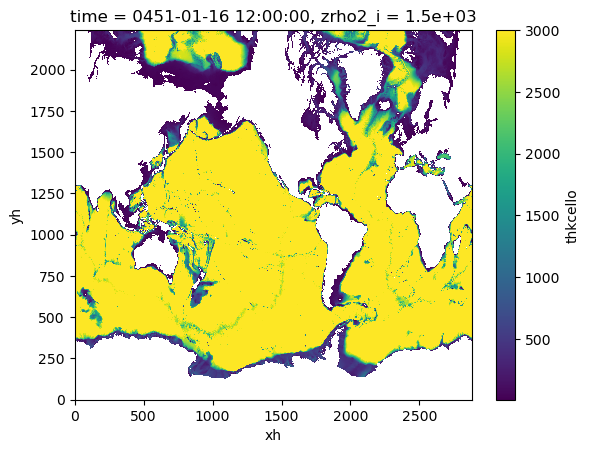

In [165]:
tmp.isel(time=0, zrho2_i=0).plot()

In [152]:
import gsw, xwmt, xhistogram

In [151]:
tmp = xhistogram.xarray.histogram(
    grid._ds.zrho2_i,
    bins=[0, 700, 3000, 6000],
    dim=("zl",),
    weights=grid._ds.rho2_l*grid._ds.thkcello.fillna(0.)*grid._ds.areacello.fillna(0.),
    bin_dim_suffix="_l",
    # TEMPORARY FIX FOR https://github.com/xgcm/xhistogram/issues/16
    block_size=None
)

<xarray.DataArray 'rho2_l' (rho2_l: 74)> Size: 592B
array([1004.24625, 1013.565  , 1017.71   , 1021.855  , 1025.96375, 1028.165  ,
       1028.495  , 1028.83   , 1029.165  , 1029.495  , 1029.83   , 1030.165  ,
       1030.495  , 1030.83   , 1031.165  , 1031.495  , 1031.83   , 1032.165  ,
       1032.495  , 1032.83   , 1033.0665 , 1033.28225, 1033.571  , 1033.8425 ,
       1034.09975, 1034.3435 , 1034.5735 , 1034.7895 , 1034.991  , 1035.17725,
       1035.348  , 1035.5035 , 1035.64475, 1035.77275, 1035.8885 , 1035.99375,
       1036.09025, 1036.17925, 1036.262  , 1036.34   , 1036.4145 , 1036.4865 ,
       1036.5565 , 1036.625  , 1036.692  , 1036.75525, 1036.812  , 1036.86125,
       1036.904  , 1036.9415 , 1036.974  , 1037.002  , 1037.02625, 1037.0475 ,
       1037.0665 , 1037.08375, 1037.1    , 1037.116  , 1037.132  , 1037.148  ,
       1037.164  , 1037.18   , 1037.1965 , 1037.2145 , 1037.235  , 1037.26   ,
       1037.2945 , 1037.345  , 1037.415  , 1037.5075 , 1037.625  , 1037.76   ,
       1037.9    , 1038.485  ])
Coordinates:
  * rho2_l   (rho2_l) float64 592B 1.004e+03 1.014e+03 ... 1.038e+03 1.038e+03
Attributes:
    long_name:  Target Potential Density at cell center
    units:      kg m-3
    axis:       Z
    positive:   down
    edges:      rho2_i

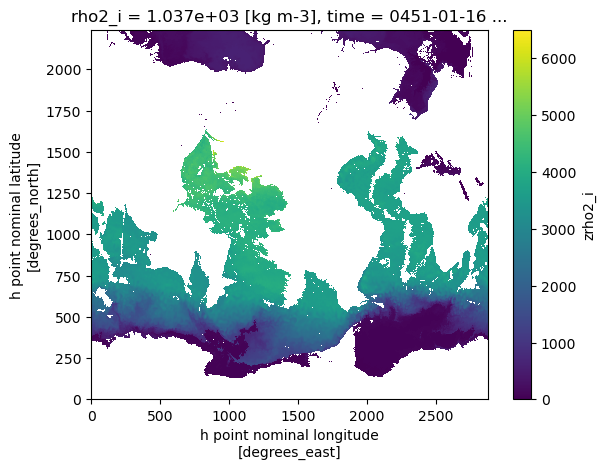

In [149]:
grid._ds.zrho2_i.isel(time=0, rho2_i=-20).plot()

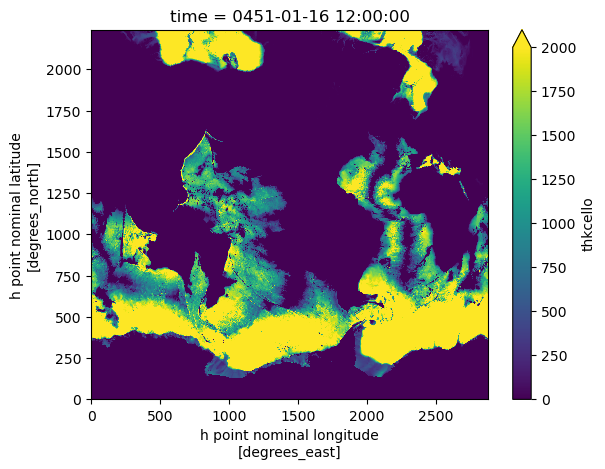

In [98]:
ds.thkcello.isel(time=0).sel(rho2_l=slice(1037.0755, None)).sum("rho2_l").plot(vmin=0, vmax=2000)

In [257]:
testing = True

print(f"Subsample {model} transient tracer output.")
dim_coarsen_dict = {"CM4Xp25": {"X":2, "Y":2}, "CM4Xp125": {"X":4, "Y":4}}
dim_coarsen = dim_coarsen_dict[model]
odivs = CM4Xutils.exp_dict[model]

def load_tracer(exp, tracers, t="*"):
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_inert_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, tracers, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)
    
    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)
    
    return ds

def load_state(exp, t="*"):
    state_vars = ["thkcello", "thetao", "so"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_z"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'z_l':ds.z_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)

    grid = CM4Xutils.ds_to_grid(ds)
    
    # Compute potential density
    diagnose_sigma2_offline(grid)
    
    return grid._ds

def load_rho2(exp, t="*"):
    # Load thickness of density layers
    state_vars = ["thkcello"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_rho2"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'rho2_l':ds.rho2_l.size}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)

    grid_rho2 = CM4Xutils.ds_to_grid(ds)

    # Get depths of density interfaces
    infer_z(grid_rho2)

    return grid_rho2

def assign_historical_dates(ds_ctrl):
    # Align dates of a control simulation (with nominal dates starting from year 1)
    # to a historically-referenced simulation (e.g. with dates starting from 1850)
    if "year" in ds_ctrl.dims:
        year_ctrl = ds_ctrl.year.copy()
        ds_ctrl = ds_ctrl.rename({"year": "year_ctrl"})
        historical_equivalent_dates = xr.DataArray(
            np.array([y+1749 for y in year_ctrl]),
            dims=("year_ctrl",)
        )
        ds_ctrl = (
            ds_ctrl
            .assign_coords({"year": historical_equivalent_dates})
            .swap_dims({"year_ctrl": "year"})
        )
    elif "time" in ds_ctrl.dims:
        time_ctrl = ds_ctrl.time.copy()
        ds_ctrl = ds_ctrl.rename({"time": "time_ctrl"})
        historical_equivalent_dates = xr.DataArray(
            np.array([
                cftime.DatetimeNoLeap(
                    int(d.dt.year) + 1749,
                    int(d.dt.month),
                    int(d.dt.day),
                    0, 0, 0, 0,
                    has_year_zero=True
                )
                for d in time_ctrl
            ]),
            dims=("time_ctrl",)
        )
        ds_ctrl = (
            ds_ctrl
            .assign_coords({"time": historical_equivalent_dates})
            .swap_dims({"time_ctrl": "time"})
        )
    
    return ds_ctrl

def add_estimated_layer_interfaces(ds):
    return ds.assign_coords({"z_i": xr.DataArray(
        np.concatenate([[0], 0.5*(ds.z_l.values[1:]+ds.z_l.values[0:-1]), [6750]]),
        dims=('z_i',)
    )})

def diagnose_sigma2_offline(grid):
    grid._ds["sigma2_offline"] = xr.apply_ufunc(
        gsw.sigma2,
        grid._ds.so,
        grid._ds.thetao,
        dask="parallelized"
    ).rename("sigma2_offline")
    grid._ds["sigma2_offline"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density',
        'description': "Diagnosed offline using the `gsw.sigma2` function on `thetao` and `so` on depth levels."
    }

def regrid_sigma2_from_rho2_diags(ds, grid_rho2):
    grid_rho2._ds["sigma2"] = grid_rho2._ds["rho2_l"] - 1000.
    sigma2 = (
        grid_rho2.transform(
            grid_rho2._ds.sigma2*grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
        / grid_rho2.transform(
            grid_rho2._ds.thkcello.fillna(0.)*grid_rho2._ds.areacello.fillna(0.),
            "Z",
            target=ds.z_i,
            target_data=grid_rho2._ds.z_i,
            method="conservative"
        ).rename({"z_i":"z_l"})
    ).transpose("time", "z_l", "yh", "xh")
    sigma2 = sigma2.assign_coords({k:ds[k] for k in ds.coords if k in sigma2.coords})
    ds["sigma2"] = sigma2
    ds["sigma2"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density',
        'description': "Regridded offline based on online thicknesses between fixed rho2 levels."
    }


def infer_z(grid, zero_ssh=True):
    zl = grid.axes['Z'].coords['center']
    zi = grid.axes['Z'].coords['outer']

    if zero_ssh:
        ssh_ref = 0 
    else:
        # CM4Xp25 does not have col_height variable available, so need to compute from thkcello
        if "col_height" not in grid._ds.data_vars:
            grid._ds["col_height"] = grid._ds["thkcello"].sum(zl)
            grid._ds["col_height"].attrs = {
                'long_name': 'The height of the water column',
                 'units': 'm',
                 'cell_methods': 'area:mean yh:mean xh:mean time: mean',
                 'cell_measures': 'area: areacello',
                 'time_avg_info': 'average_T1,average_T2,average_DT'
            }
        ssh_ref = grid._ds.col_height - grid._ds.deptho

    # Interface depths
    thkcello_cumsum = (
        xr.concat([
            xr.zeros_like(grid._ds.thkcello.isel({zl:0})).expand_dims({zl:[0]}),
            grid._ds.thkcello.cumsum(zl),
        ],dim=zl)
        .rename({zl:zi})
        .assign_coords({zi:grid._ds[zi].values})
    )
    grid._ds["z_i"] = (
        (thkcello_cumsum - ssh_ref)
        .transpose("time", zi, "yh", "xh")
    ).chunk({zi: grid._ds[zi].size})
    grid._ds["z_i"].attrs = {
        'long_name': 'depth of layer interfaces',
        'units': 'm',
        'cell_methods': f'area:mean {zi}:point yh:mean xh:mean time: mean',
        'cell_measures': 'area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

    # Center depths
    zl_extended = np.concatenate((
        grid._ds[zi][np.array([0])].values,
        grid._ds[zl].values,
        grid._ds[zi][np.array([-1])].values
    ))

    grid._ds["thkcello_i"] = grid.transform(
        grid._ds["thkcello"].fillna(0.),
        "Z",
        zl_extended,
        method="conservative",
    ).assign_coords({zi:grid._ds[zi].values}).transpose("time", zi, "yh", "xh")

    grid._ds["z_l"] = (
        (grid.cumsum(grid._ds.thkcello_i, "Z", to="center") - ssh_ref)
        .transpose("time", zl, "yh", "xh")
    ).chunk({zl: grid._ds[zl].size})
    grid._ds["z_l"].attrs = {
        'long_name': 'depth of layer centers',
        'units': 'm',
        'cell_methods': f'area:mean {zl}:point yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

def load(exp, tracers, t="*"):
    try:
        ds_tracer = load_tracer(exp, tracers, t=t)
    except:
        ds_tracer = xr.Dataset()
    ds_state = load_state(exp, t=t)
    ds = xr.merge([ds_tracer, ds_state], compat="override")

    # Get accurate density field on depth levels from thkcello(rho2_l)
    grid_rho2 = load_rho2(exp, t=t)
    regrid_sigma2_from_rho2_diags(ds, grid_rho2)
    
    grid = CM4Xutils.ds_to_grid(ds)
    return grid

time_ranges = {
    "CM4Xp25": {
        "historical": [1850, 2015],
        "ssp585": [2015, 2100],
        "piControl": [101, 361],
        "piControl-continued": [361, 651],
    },
    "CM4Xp125": {
        "historical": [1850, 2015],
        "ssp585": [2015, 2100],
        "piControl": [101, 451],
        "piControl-continued": [451, 651],
    }
}

with warnings.catch_warnings(action='ignore', category=UserWarning):
    for exp, t_range in time_ranges[model].items():
        coarse_path = f"../data/interim/{model}_{exp}_transient_tracers_z.zarr"  # one per exp
        surface_path = f"../data/interim/{model}_{exp}_transient_tracers_surface.zarr"  # one per exp

        mode = "w" # overwrite if .zarr already file exists
        for t in np.arange(t_range[0], t_range[1], 5):
            tstr = f"{str(t).zfill(4)}*"
            print(f"Coarsening tracers for {model}-{exp} for {tstr}")

            with dask.config.set(**{'array.slicing.split_large_chunks': False}):
                grid = load(odivs[exp], ["cfc11", "cfc12", "sf6"], t=tstr)
                
                ds_mean = grid._ds.groupby("time.year").mean("time")
                ds_coarse = CM4Xutils.coarsen.horizontally_coarsen(ds_mean, grid, dim_coarsen)
                
                ds_surface = grid._ds.isel(z_l=[0])
                ds_surface_coarse = CM4Xutils.coarsen.horizontally_coarsen(ds_surface, grid, dim_coarsen)
                
                if "piControl" in exp:
                    ds_coarse = assign_historical_dates(ds_coarse)
                    ds_surface_coarse = assign_historical_dates(ds_surface_coarse)
            break
        break

Subsample CM4Xp125 transient tracer output.
Coarsening tracers for CM4Xp125-historical for 1850*
Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: depth `z_`
Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: density `rho2`


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(


Inferring Z grid coordinate: depth `z_`
Skipping average_DT because independent of 'X' and 'Y' dims.
Skipping average_DT because independent of 'X' and 'Y' dims.
Skipping average_T1 because independent of 'X' and 'Y' dims.
Skipping average_T2 because independent of 'X' and 'Y' dims.
Skipping time_bnds because independent of 'X' and 'Y' dims.


In [256]:
display(ds_coarse)
display(ds_surface_coarse)

<xarray.Dataset> Size: 2GB
Dimensions:         (z_l: 35, yh: 560, xh: 720, year: 5, xq: 721, yq: 561)
Coordinates: (12/23)
  * z_l             (z_l) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
    areacello       (yh, xh) float64 3MB 1.057e+08 1.056e+08 ... 4.864e+06
    geolon          (yh, xh) float64 3MB -298.5 -298.0 -297.5 ... 59.99 60.0
    lon             (yh, xh) float64 3MB -298.5 -298.0 -297.5 ... 59.99 60.0
    geolat          (yh, xh) float64 3MB -82.4 -82.4 -82.39 ... 64.36 64.14
    lat             (yh, xh) float64 3MB -82.4 -82.4 -82.39 ... 64.36 64.14
    ...              ...
    geolon_v        (yq, xh) float64 3MB -298.4 -297.9 -297.5 ... 60.0 60.0 60.0
    geolat_v        (yq, xh) float64 3MB -82.47 -82.47 -82.46 ... 64.36 64.14
  * xh              (xh) int64 6kB 0 1 2 3 4 5 6 ... 713 714 715 716 717 718 719
  * yh              (yh) int64 4kB 0 1 2 3 4 5 6 ... 553 554 555 556 557 558 559
  * xq              (xq) int64 6kB 0 1 2 3 4 5 6 ... 714 715 716 717 718 719 720
  * yq              (yq) int64 4kB 0 1 2 3 4 5 6 ... 554 555 556 557 558 559 560
Data variables:
    cfc11           (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    cfc12           (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    sf6             (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    so              (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    thetao          (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    thkcello        (year, z_l, yh, xh) float32 282MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
    sigma2_offline  (year, z_l, yh, xh) float64 564MB dask.array<chunksize=(1, 35, 560, 720), meta=np.ndarray>
Attributes:
    filename:            ocean_inert_z.185001-185412.cfc11.nc
    title:               CM4_historical_c192_OM4p125
    associated_files:    areacello: 18500101.ocean_static.nc
    grid_type:           regular
    grid_tile:           N/A
    external_variables:  volcello areacello
    provenance:          Diagnostics have been conservatively coarsened by He...

<xarray.Dataset> Size: 823MB
Dimensions:         (time: 60, z_l: 1, yh: 560, xh: 720, xq: 721, yq: 561)
Coordinates: (12/23)
  * time            (time) object 480B 1850-01-16 12:00:00 ... 1854-12-16 12:...
  * z_l             (z_l) float64 8B 2.5
    areacello       (yh, xh) float64 3MB 1.057e+08 1.056e+08 ... 4.864e+06
    geolon          (yh, xh) float64 3MB -298.5 -298.0 -297.5 ... 59.99 60.0
    lon             (yh, xh) float64 3MB -298.5 -298.0 -297.5 ... 59.99 60.0
    geolat          (yh, xh) float64 3MB -82.4 -82.4 -82.39 ... 64.36 64.14
    ...              ...
    geolon_v        (yq, xh) float64 3MB -298.4 -297.9 -297.5 ... 60.0 60.0 60.0
    geolat_v        (yq, xh) float64 3MB -82.47 -82.47 -82.46 ... 64.36 64.14
  * xh              (xh) int64 6kB 0 1 2 3 4 5 6 ... 713 714 715 716 717 718 719
  * yh              (yh) int64 4kB 0 1 2 3 4 5 6 ... 553 554 555 556 557 558 559
  * xq              (xq) int64 6kB 0 1 2 3 4 5 6 ... 714 715 716 717 718 719 720
  * yq              (yq) int64 4kB 0 1 2 3 4 5 6 ... 554 555 556 557 558 559 560
Data variables:
    cfc11           (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    cfc12           (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    sf6             (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    so              (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    thetao          (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    thkcello        (time, z_l, yh, xh) float32 97MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
    sigma2_offline  (time, z_l, yh, xh) float64 194MB dask.array<chunksize=(60, 1, 560, 720), meta=np.ndarray>
Attributes:
    filename:            ocean_inert_z.185001-185412.cfc11.nc
    title:               CM4_historical_c192_OM4p125
    associated_files:    areacello: 18500101.ocean_static.nc
    grid_type:           regular
    grid_tile:           N/A
    external_variables:  volcello areacello
    provenance:          Diagnostics have been conservatively coarsened by He...